# 🔍 05 — Explainability (SHAP + Attention)
### Data Flow
```
data/02_train.csv  ─┐
data/02_test.csv   ─┤→ SHAP + Attention → plots
outputs/best_model.pth
```


In [1]:

import warnings; warnings.filterwarnings('ignore')
import sys; sys.path.insert(0, '..')
import os, torch, shap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from src.model import CreditRiskDNN

os.makedirs('plots', exist_ok=True)
sns.set_theme(style='whitegrid', font_scale=1.1)


## 1. Load Data + Model

In [2]:

df_train      = pd.read_csv('../data/02_train.csv')
df_test       = pd.read_csv('../data/02_test.csv')
feature_names = [c for c in df_train.columns if c != 'DEFAULT']

X_train = df_train[feature_names].values.astype(np.float32)
X_test  = df_test[feature_names].values.astype(np.float32)
y_test  = df_test['DEFAULT'].values.astype(int)

model = CreditRiskDNN(n_features=len(feature_names))
model.load_state_dict(torch.load('../outputs/best_model.pth', map_location='cpu'))
model.eval()
print("✅ Data and model loaded")
print(f"   Train: {X_train.shape}  |  Test: {X_test.shape}")


✅ Data and model loaded
   Train: (22241, 23)  |  Test: (6542, 23)


## 2. Feature Attention Weights

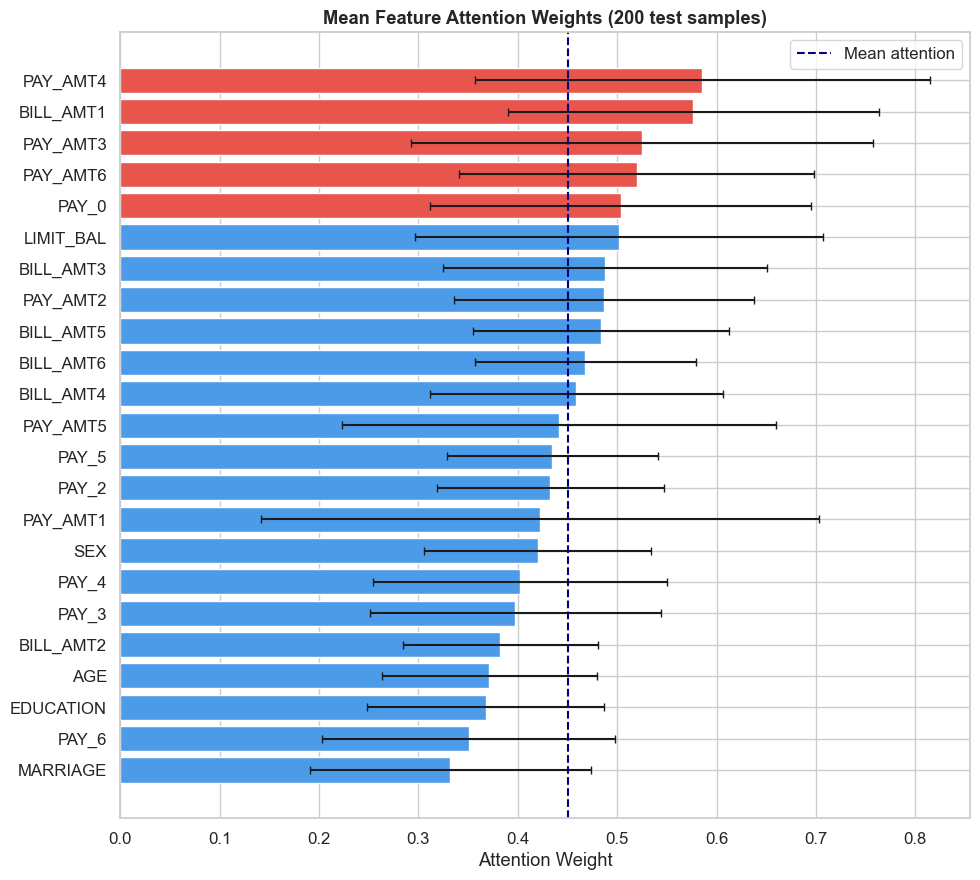

In [3]:

with torch.no_grad():
    _, attn = model(torch.tensor(X_test[:200]))
    attn_np  = attn.numpy()

mean_attn = attn_np.mean(axis=0)
std_attn  = attn_np.std(axis=0)
sorted_idx = mean_attn.argsort()

fig, ax = plt.subplots(figsize=(10, 9))
colors  = ['#E8554C' if i >= len(sorted_idx)-5 else '#4C9BE8'
           for i in range(len(sorted_idx))]
ax.barh([feature_names[i] for i in sorted_idx],
        mean_attn[sorted_idx],
        xerr=std_attn[sorted_idx],
        color=colors, edgecolor='white', capsize=3)
ax.axvline(mean_attn.mean(), color='navy', linestyle='--', label='Mean attention')
ax.set_title('Mean Feature Attention Weights (200 test samples)', fontweight='bold')
ax.set_xlabel('Attention Weight')
ax.legend()
plt.tight_layout()
plt.savefig('plots/05_attention_weights.png', dpi=150, bbox_inches='tight')
plt.show()


## 3. SHAP Global Importance

  0%|          | 0/100 [00:00<?, ?it/s]

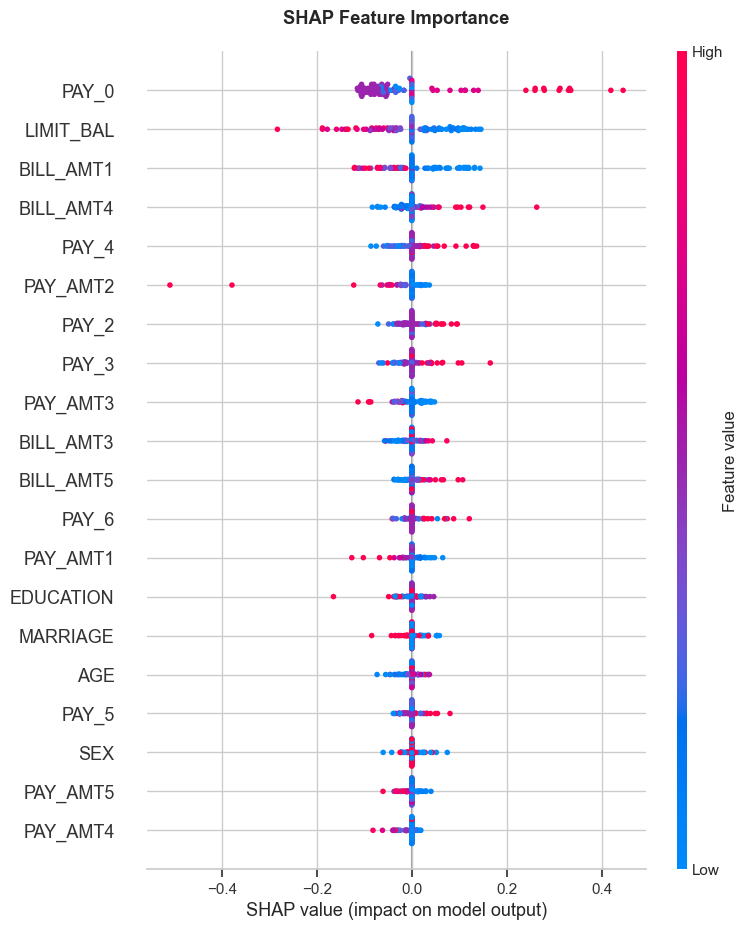

In [4]:

def model_predict(X_np):
    X_t = torch.tensor(np.array(X_np, dtype=np.float32))
    with torch.no_grad():
        probs = torch.sigmoid(model(X_t)[0]).numpy()
    return np.atleast_1d(probs.reshape(-1))

background  = shap.sample(X_train, 100)
explainer   = shap.KernelExplainer(model_predict, background)
shap_values = explainer.shap_values(X_test[:100], nsamples=100)

plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test[:100],
                  feature_names=feature_names, show=False)
plt.title('SHAP Feature Importance', fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('plots/05_shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()


## 4. SHAP Bar Chart

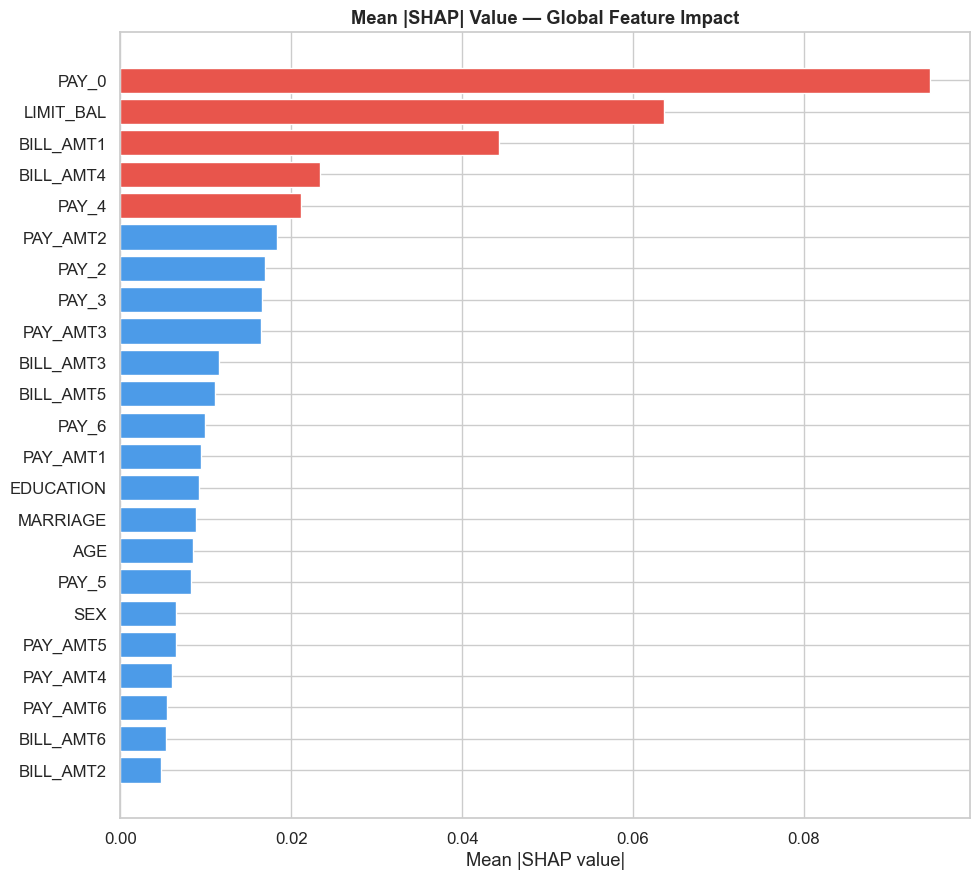

Top 5 most impactful features:
  feature  mean_abs_shap
    PAY_0       0.094739
LIMIT_BAL       0.063596
BILL_AMT1       0.044365
BILL_AMT4       0.023416
    PAY_4       0.021105


In [5]:

mean_shap = np.abs(shap_values).mean(axis=0)
shap_df   = pd.DataFrame({'feature': feature_names, 'mean_abs_shap': mean_shap})              .sort_values('mean_abs_shap', ascending=True)

fig, ax = plt.subplots(figsize=(10, 9))
colors  = ['#E8554C' if i >= len(shap_df)-5 else '#4C9BE8'
           for i in range(len(shap_df))]
ax.barh(shap_df['feature'], shap_df['mean_abs_shap'], color=colors, edgecolor='white')
ax.set_title('Mean |SHAP| Value — Global Feature Impact', fontweight='bold')
ax.set_xlabel('Mean |SHAP value|')
plt.tight_layout()
plt.savefig('plots/05_shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()

print("Top 5 most impactful features:")
print(shap_df.tail(5).sort_values('mean_abs_shap', ascending=False).to_string(index=False))


## 5. SHAP Waterfall — Individual Predictions

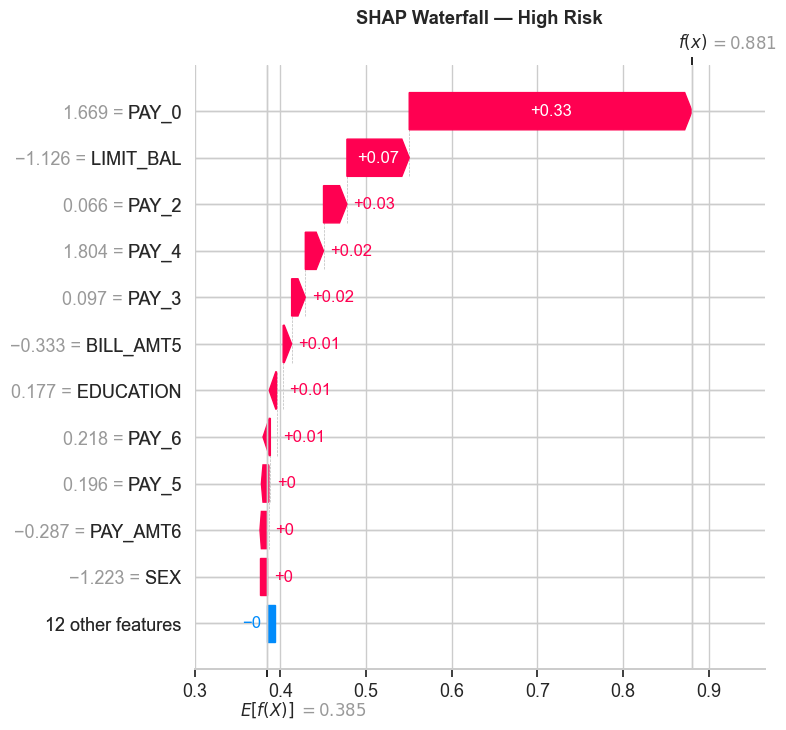

High Risk | Actual: 1 | Predicted prob: 0.8805



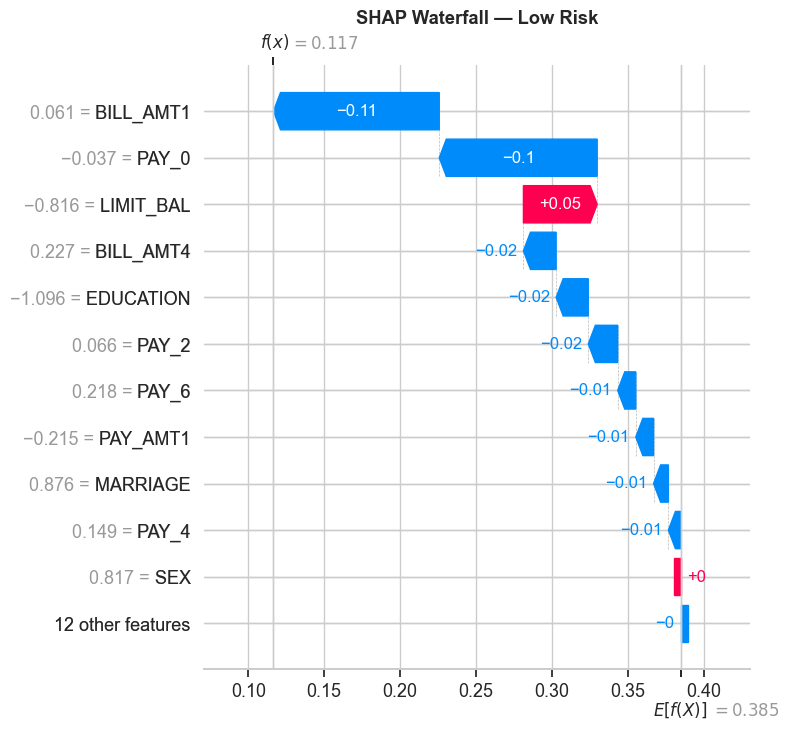

Low Risk | Actual: 0 | Predicted prob: 0.1166



In [6]:

for idx, label in [(np.where(y_test==1)[0][0], 'High Risk'),
                   (np.where(y_test==0)[0][0], 'Low Risk')]:
    exp = shap.Explanation(
        values=shap_values[idx],
        base_values=float(explainer.expected_value),
        data=X_test[idx],
        feature_names=feature_names
    )
    shap.plots.waterfall(exp, show=False, max_display=12)
    plt.title(f'SHAP Waterfall — {label}', fontweight='bold')
    plt.tight_layout()
    fname = label.lower().replace(' ', '_')
    plt.savefig(f'plots/05_shap_waterfall_{fname}.png', dpi=150, bbox_inches='tight')
    plt.show()
    prob = model_predict(X_test[idx:idx+1])[0]
    print(f"{label} | Actual: {y_test[idx]} | Predicted prob: {prob:.4f}\n")
